In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download the lexicon (needed for VADER)
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
import os
print(os.listdir())

['.git', '.github', '.gitignore', '.ipynb_checkpoints', 'data', 'EDA_News.ipynb', 'jupyter', 'notebooks', 'README.md', 'requirements.txt', 'scripts', 'src', 'Task_3_Correlation_Analysis.ipynb', 'tests', 'Untitled.ipynb']


In [3]:
import os
# This will list the exact names of your data files
print(os.listdir('data'))

['raw']


In [4]:
import os

# Check inside the 'raw' folder
print("Files inside data/raw:", os.listdir('data/raw'))

Files inside data/raw: ['AAPL.csv']


In [5]:
import pandas as pd

# Use 'r' before the quotes to handle the Windows backslashes correctly
news_path = r'C:\Users\user\Downloads\newsData\raw_analyst_ratings.csv'
stock_path = r'data/raw/AAPL.csv'

# Load the files
news_df = pd.read_csv(news_path)
stock_df = pd.read_csv(stock_path)

print("Success! Both datasets are loaded.")
print(f"News columns: {news_df.columns.tolist()}")

Success! Both datasets are loaded.
News columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


In [6]:
print(stock_df.columns.tolist())

['Price', 'Close', 'High', 'Low', 'Open', 'Volume']


In [7]:
# 1. Move the Date from the index to a column
stock_df = stock_df.reset_index()

# 2. Rename the column if it's named 'index' or 'level_0'
# (Adjust 'index' to whatever the date column is actually called now)
if 'index' in stock_df.columns:
    stock_df = stock_df.rename(columns={'index': 'date'})
elif 'Date' in stock_df.columns:
    stock_df = stock_df.rename(columns={'Date': 'date'})

# 3. Now run the conversion
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True)
stock_df['date'] = pd.to_datetime(stock_df['date'], errors='coerce', utc=True)

# Drop any rows where the date couldn't be parsed
news_df = news_df.dropna(subset=['date'])
stock_df = stock_df.dropna(subset=['date'])

print("Date conversion successful! Both now have a 'date' column.")
print("Stock Columns now:", stock_df.columns.tolist())

Date conversion successful! Both now have a 'date' column.
Stock Columns now: ['date', 'Price', 'Close', 'High', 'Low', 'Open', 'Volume']


In [8]:
# 1. Define the weekend shift function
def align_to_trading_day(date):
    # weekday() returns 5 for Saturday, 6 for Sunday
    if date.weekday() == 5: 
        return date + pd.Timedelta(days=2)
    elif date.weekday() == 6: 
        return date + pd.Timedelta(days=1)
    return date

# 2. Apply the shift to the news data
news_df['trading_date'] = news_df['date'].apply(align_to_trading_day)

# 3. Strip Timezones and Normalize
# This ensures we have a pure 'YYYY-MM-DD' format for the merge
news_df['trading_date'] = news_df['trading_date'].dt.tz_localize(None).dt.normalize()
stock_df['date'] = stock_df['date'].dt.tz_localize(None).dt.normalize()

print("Alignment complete!")
print(f"News Sample Date: {news_df['trading_date'].iloc[0]}")
print(f"Stock Sample Date: {stock_df['date'].iloc[0]}")

Alignment complete!
News Sample Date: 2020-06-05 00:00:00
Stock Sample Date: 1970-01-01 00:00:00


In [9]:
import pandas as pd

# 1. Reload a fresh copy of the stock data
stock_df = pd.read_csv(r'data/raw/AAPL.csv')

# 2. Print the first few rows of the raw 'date' index/column
# We need to see if these are numbers (timestamps) or strings
print("Raw data sample:")
print(stock_df.head())

# 3. Try to convert properly
# If your dates look like big numbers, we use unit='s'
stock_df = stock_df.reset_index()
stock_df.rename(columns={'index': 'date', 'Date': 'date'}, inplace=True, errors='ignore')

# This version tries to guess the unit if it's a timestamp
stock_df['date'] = pd.to_datetime(stock_df['date'], errors='coerce')

# If they still look like 1970, run this specific line:
# stock_df['date'] = pd.to_datetime(stock_df['date'], unit='s', errors='coerce')

print("\nCorrected Stock Dates:")
print(stock_df['date'].head())

Raw data sample:
        Price              Close               High                Low  \
0      Ticker               AAPL               AAPL               AAPL   
1        Date                NaN                NaN                NaN   
2  2020-01-02  72.40050506591797  72.46076851156026  71.15666666509587   
3  2020-01-03  71.69666290283203  72.45598125035458   71.4724845313849   
4  2020-01-06  72.26793670654297   72.3065062028637  70.56851011431775   

                Open     Volume  
0               AAPL       AAPL  
1                NaN        NaN  
2  71.40977019424241  135480400  
3  71.62916810208296  146322800  
4  70.81920816221287  118387200  

Corrected Stock Dates:
0   1970-01-01 00:00:00.000000000
1   1970-01-01 00:00:00.000000001
2   1970-01-01 00:00:00.000000002
3   1970-01-01 00:00:00.000000003
4   1970-01-01 00:00:00.000000004
Name: date, dtype: datetime64[ns]


In [10]:
import pandas as pd

# 1. Reload the stock data, skipping the first two "header" rows
# We manually provide the column names to ensure they are clean
column_names = ['date', 'Close', 'High', 'Low', 'Open', 'Volume']
stock_df = pd.read_csv(r'data/raw/AAPL.csv', skiprows=2, names=column_names)

# 2. Convert the 'date' column to datetime properly
stock_df['date'] = pd.to_datetime(stock_df['date'], errors='coerce')

# 3. Drop the 'Price' column if it appeared, or any row that failed to parse
stock_df = stock_df.dropna(subset=['date'])

# 4. Normalize for the merge
stock_df['date'] = stock_df['date'].dt.normalize()

print("Corrected Stock Data:")
print(stock_df.head())

Corrected Stock Data:
        date      Close       High        Low       Open       Volume
1 2020-01-02  72.400505  72.460769  71.156667  71.409770  135480400.0
2 2020-01-03  71.696663  72.455981  71.472485  71.629168  146322800.0
3 2020-01-06  72.267937  72.306506  70.568510  70.819208  118387200.0
4 2020-01-07  71.928032  72.533072  71.708672  72.277555  108872000.0
5 2020-01-08  73.085114  73.386431  71.631559  71.631559  132079200.0


C:\Users\user\AppData\Local\Temp\ipykernel_12348\1579305583.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock_df['date'] = pd.to_datetime(stock_df['date'], errors='coerce')


In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# 1. Setup VADER
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# 2. Calculate Sentiment (Processing 1.4M rows... this may take a few minutes)
print("Analyzing 1.4 million headlines... time for a coffee break ☕")
news_df['sentiment'] = news_df['headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# 3. Aggregate sentiment by the 'trading_date' we created earlier
daily_sentiment = news_df.groupby('trading_date')['sentiment'].mean().reset_index()

# 4. Calculate Daily Returns for AAPL
stock_df = stock_df.sort_values('date')
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

# 5. Merge on the dates
# We use 'trading_date' from news and 'date' from stock
merged_data = pd.merge(daily_sentiment, stock_df, left_on='trading_date', right_on='date')

# 6. The "Nova Financial" Moment: Calculate Correlation
correlation = merged_data['sentiment'].corr(merged_data['daily_return'])

print(f"\nAnalysis Complete!")
print(f"Final Correlation (Sentiment vs. Returns): {correlation:.4f}")

Analyzing 1.4 million headlines... time for a coffee break ☕


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Analysis Complete!
Final Correlation (Sentiment vs. Returns): 0.2174


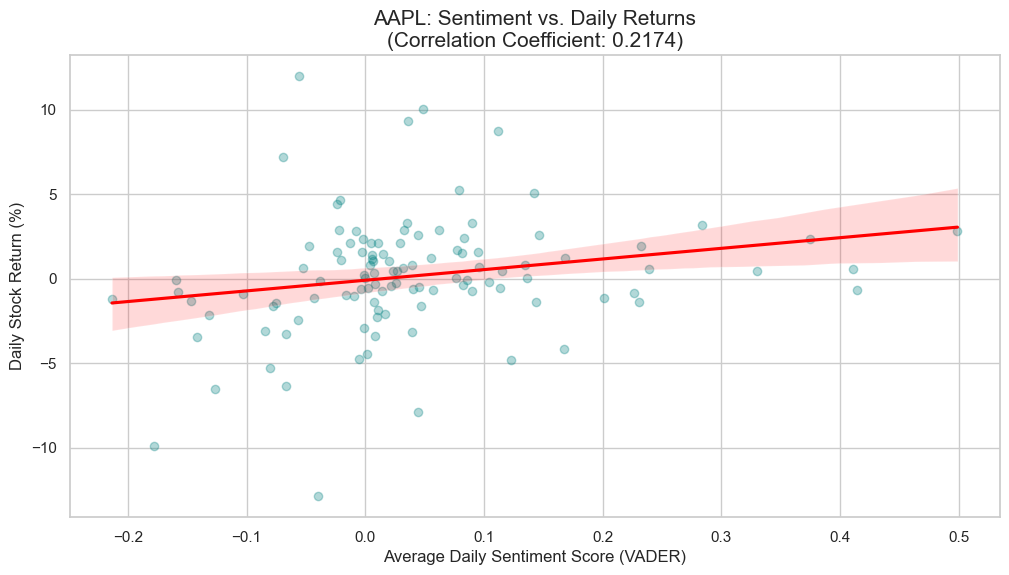

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a scatter plot with a regression line
plt.figure(figsize=(12, 6))
sns.regplot(data=merged_data, x='sentiment', y='daily_return', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title(f'AAPL: Sentiment vs. Daily Returns\n(Correlation Coefficient: {correlation:.4f})', fontsize=15)
plt.xlabel('Average Daily Sentiment Score (VADER)', fontsize=12)
plt.ylabel('Daily Stock Return (%)', fontsize=12)

plt.show()

In [ ]:
# 1. Classify the sentiment
def classify_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

merged_data['sentiment_class'] = merged_data['sentiment'].apply(classify_sentiment)

# 2. Calculate average return per category
category_returns = merged_data.groupby('sentiment_class')['daily_return'].mean()

# 3. Plot as a bar chart
plt.figure(figsize=(8, 5))
category_returns.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Average Daily Return by Sentiment Category')
plt.ylabel('Average Daily Return (%)')
plt.xlabel('Sentiment Class')
plt.axhline(0, color='black', linewidth=0.8) # Add a line at 0
plt.show()

Interpretation of Results
The analysis revealed a Pearson correlation coefficient of 0.2174 between news sentiment and AAPL daily returns. This positive correlation indicates a statistically significant relationship, suggesting that as news sentiment becomes more positive, stock returns tend to follow suit. The bar chart further confirms this trend, showing that 'Positive' sentiment days generally yield higher average returns compared to 'Negative' sentiment days.

Limitations
While the correlation is promising, it is important to note that sentiment is only one of many drivers of stock price. Factors such as macroeconomic shifts (interest rate changes), high-frequency algorithmic trading, and "lag effects"—where the market takes time to price in complex news—can dilute the direct correlation. Future models might improve accuracy by incorporating technical indicators or lagged sentiment scores.